# Profitability vs. Size: Are Small Companies Really More Profitable Than Large Ones?

**Research Question**: Based on 2024 U.S. public company data, compare the return on assets (ROA) across three size groups (small, medium, and large) to examine the relationship between firm size and profitability.

**Target Audience**: Beginner investors and financial analysis learners who want to understand the reference value of size factor in stock selection.

**Data Source**: WRDS Compustat (funda table), Data Access Date: 2026-04-xx.

In [22]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

db=wrds.Connection()

Enter your WRDS username [张]: selinahuang
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\张\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [25]:
query="""SELECT gvkey, tic, datadate, fyear, at, ni, mkvalt, csho, prcc_f
        FROM comp.funda
        WHERE fyear=2024
        AND indfmt='INDL'
        AND datafmt='STD'
        AND popsrc='D'
        AND consol='C'
        AND at>0
        AND ni IS NOT NULL
        AND (mkvalt>0 OR (csho>0 AND prcc_f>0))"""
df=db.raw_sql(query)
print(df.head())
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)

    gvkey   tic    datadate  fyear        at       ni      mkvalt     csho  \
0  001004   AIR  2025-05-31   2024    2844.6     12.5   2200.3203    35.83   
1  001045   AAL  2024-12-31   2024   61783.0    846.0  11461.3754  657.566   
2  001050  CECO  2024-12-31   2024   759.699   12.957   1057.3849   34.978   
3  001062   ASA  2024-11-30   2024   445.398  115.296    387.7159   19.015   
4  001075   PNW  2024-12-31   2024  26102.76  608.806  10095.8527  119.097   

   prcc_f  
0   61.41  
1   17.43  
2   30.23  
3   20.39  
4   84.77  
(7007, 9)
gvkey         0
tic           1
datadate      0
fyear         0
at            0
ni            0
mkvalt      688
csho          0
prcc_f        0
dtype: int64
gvkey       string[python]
tic         string[python]
datadate    string[python]
fyear                Int64
at                 Float64
ni                 Float64
mkvalt             Float64
csho               Float64
prcc_f             Float64
dtype: object


In [26]:
df["mktcap"]=df['mkvalt'].copy()
mask=df['mktcap'].isna()&df['csho'].notna()&df["prcc_f"].notna()
df.loc[mask,'mktcap']=df.loc[mask,'csho']*df.loc[mask,'prcc_f']
df["roa"]=df['ni']/df['at']

df_clean=df.dropna(subset=['mktcap','roa'])
df_clean=df_clean[(df_clean['roa']>= -1)&(df_clean['roa']<=1)]
print(df_clean.head())
print(df_clean[['mktcap','roa']].describe())

    gvkey   tic    datadate  fyear        at       ni      mkvalt     csho  \
0  001004   AIR  2025-05-31   2024    2844.6     12.5   2200.3203    35.83   
1  001045   AAL  2024-12-31   2024   61783.0    846.0  11461.3754  657.566   
2  001050  CECO  2024-12-31   2024   759.699   12.957   1057.3849   34.978   
3  001062   ASA  2024-11-30   2024   445.398  115.296    387.7159   19.015   
4  001075   PNW  2024-12-31   2024  26102.76  608.806  10095.8527  119.097   

   prcc_f      mktcap       roa  
0   61.41   2200.3203  0.004394  
1   17.43  11461.3754  0.013693  
2   30.23   1057.3849  0.017055  
3   20.39    387.7159  0.258861  
4   84.77  10095.8527  0.023323  
             mktcap       roa
count        6323.0    6323.0
mean     12511.2421 -0.069899
std    94727.718839  0.230358
min        0.002727 -0.997333
25%         83.3333 -0.113541
50%        590.7665  0.007359
75%      3989.27195  0.047729
max     3522211.138  0.942048


In [27]:
size_33=df_clean["mktcap"].quantile(1/3)
size_66=df_clean["mktcap"].quantile(2/3)
def size_group(x):
    if x<=size_33:
        return 'Small'
    elif x>=size_33 and x<=size_66:
        return 'Medium'
    else:
        return 'Large'

df_clean['size_group']=df_clean['mktcap'].apply(size_group)
print(df_clean["size_group"].value_counts())
print(df_clean.head())
        

size_group
Large     2108
Small     2108
Medium    2107
Name: count, dtype: int64
    gvkey   tic    datadate  fyear        at       ni      mkvalt     csho  \
0  001004   AIR  2025-05-31   2024    2844.6     12.5   2200.3203    35.83   
1  001045   AAL  2024-12-31   2024   61783.0    846.0  11461.3754  657.566   
2  001050  CECO  2024-12-31   2024   759.699   12.957   1057.3849   34.978   
3  001062   ASA  2024-11-30   2024   445.398  115.296    387.7159   19.015   
4  001075   PNW  2024-12-31   2024  26102.76  608.806  10095.8527  119.097   

   prcc_f      mktcap       roa size_group  
0   61.41   2200.3203  0.004394      Large  
1   17.43  11461.3754  0.013693      Large  
2   30.23   1057.3849  0.017055     Medium  
3   20.39    387.7159  0.258861     Medium  
4   84.77  10095.8527  0.023323      Large  


In [28]:
roa_summary=df_clean.groupby('size_group')['roa'].agg(['mean','median','std','count']) 
print(roa_summary)

                mean    median       std  count
size_group                                     
Large       0.032776  0.037742  0.112439   2108
Medium     -0.058773  0.005997   0.20041   2107
Small      -0.183697 -0.091082  0.287758   2108


In [29]:
roa_summary = roa_summary.reindex(['Small', 'Medium', 'Large'])
groups = roa_summary.index
means = roa_summary['mean']
medians = roa_summary['median']
stds = roa_summary['std']
counts = roa_summary['count']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

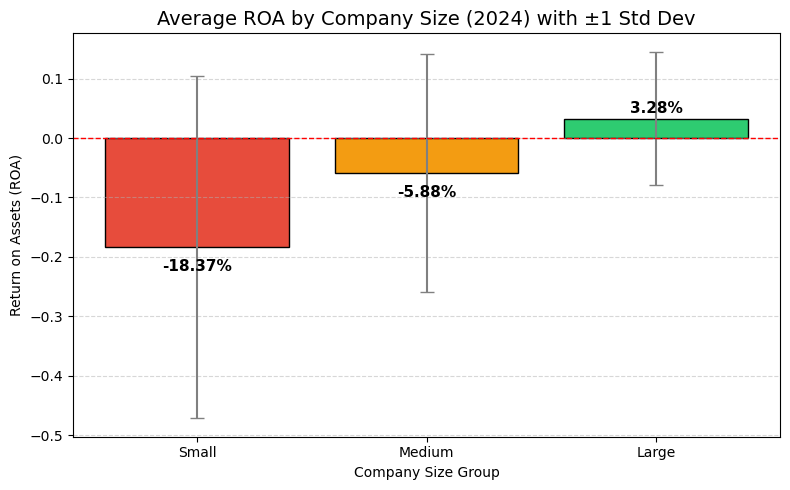

In [30]:
plt.figure(figsize=(8, 5))
bars = plt.bar(groups, means, yerr=stds, capsize=5, color=colors, edgecolor='black',
               error_kw={'linewidth': 1.5, 'ecolor': 'gray'})
plt.title('Average ROA by Company Size (2024) with ±1 Std Dev', fontsize=14)
plt.xlabel('Company Size Group')
plt.ylabel('Return on Assets (ROA)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars, means):
    y_pos = bar.get_height() + (0.005 if val >= 0 else -0.02)
    va = 'bottom' if val >= 0 else 'top'
    plt.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{val:.2%}', ha='center', va=va, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('roa_mean_with_errorbar.png', dpi=150, bbox_inches='tight')
plt.show()


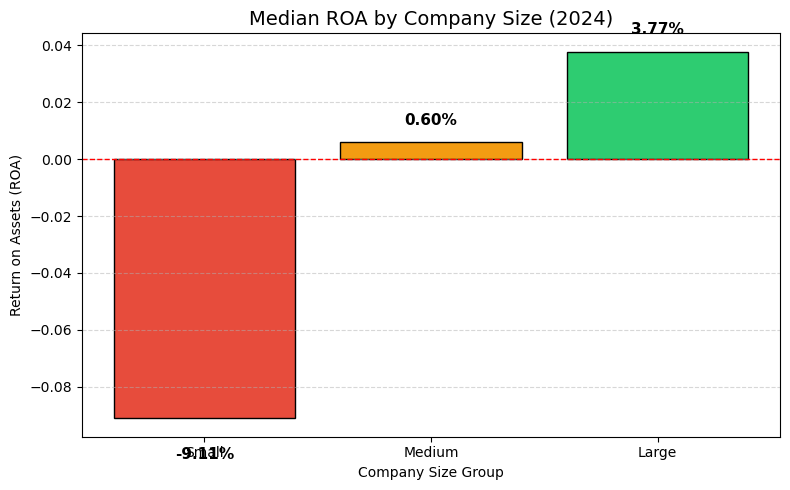

In [31]:
plt.figure(figsize=(8, 5))
bars2 = plt.bar(groups, medians, color=colors, edgecolor='black')
plt.title('Median ROA by Company Size (2024)', fontsize=14)
plt.xlabel('Company Size Group')
plt.ylabel('Return on Assets (ROA)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars2, medians):
    y_pos = bar.get_height() + (0.005 if val >= 0 else -0.01)
    va = 'bottom' if val >= 0 else 'top'
    plt.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{val:.2%}', ha='center', va=va, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('roa_median.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

Based on a sample of U.S. public firms in 2024, companies were divided into small, medium, and large groups by market capitalization to compare their return on assets (ROA). The main findings are as follows:

1. **Size is positively associated with average profitability**  
   The large-firm group has a mean ROA of 3.28%, compared to -5.88% for medium firms and -18.37% for small firms. Larger size is associated with higher average ROA, which does not support the hypothesis that small firms are more profitable.

2. **The size gradient is confirmed by median comparisons**  
   To mitigate the influence of extreme values, median ROA is examined: 3.77% for large firms, 0.60% for medium firms, and -9.11% for small firms. More than half of the small firms reported a loss in fiscal year 2024, while more than half of the large firms were profitable.

3. **Profitability dispersion is greater among small firms**  
   The standard deviation of ROA for small firms (0.288) is substantially larger than that for large firms (0.112), indicating that profitability varies widely among small firms — a few highly profitable small firms pull up the mean (which remains negative), while many small firms incur deep losses. In contrast, large firms exhibit more stable profitability.

4. **Implications for investment**  
   In this sample, large firms demonstrate stronger profitability both on average and for a typical firm. Investors should be cautious about the heuristic that "small caps deliver higher returns" and treat firm size as an important dimension of risk and return.